<a href="https://colab.research.google.com/github/grjadhav409/Prediction-of-active-molecules-against-breast-cancer-cells/blob/main/2_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Load libraries
import numpy as np
import pandas as pd
from matplotlib import pyplot
from pandas import read_csv
from pandas import set_option
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier

In [ ]:
# Split-out validation dataset

X = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/NCL/X_rdkit.csv")
Y = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/NCL/Y.csv")
validation_size = 0.20
seed = 7
X_train, X_validation, Y_train, Y_validation = train_test_split(X, Y, test_size=validation_size, random_state=seed)

In [ ]:
X_validation


,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,198,199,200,201,202,203,204,205,206,207
11402,11402,13.963718,-0.836956,13.963718,0.096442,0.349040,532.524,507.324,532.164579,200.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25456,25456,14.471149,-0.772845,14.471149,0.000402,0.242224,483.277,469.165,482.026953,156.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9012,9012,13.364341,-0.224926,13.364341,0.218335,0.558139,363.437,340.253,363.170319,138.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19596,19596,14.593209,-0.790419,14.593209,0.010520,0.201602,611.888,552.416,611.442947,248.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0
28764,28764,9.378936,0.217637,9.378936,0.217637,0.335842,438.533,414.341,438.159437,160.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24548,24548,11.594044,-0.311300,11.594044,0.050072,0.582439,260.289,244.161,260.104859,100.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10835,10835,11.886835,-0.588921,11.886835,0.176107,0.488438,481.509,454.293,481.196134,184.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17758,17758,13.294800,-0.229922,13.294800,0.223330,0.576641,349.410,328.242,349.154669,132.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3645,3645,11.917542,-0.052380,11.917542,0.052380,0.320212,442.624,402.304,442.306419,176.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0


In [ ]:
#load X and Y
df1= pd.read_csv("/content/drive/MyDrive/Colab Notebooks/NCL/X_rdkit.csv")
df2= pd.read_csv("/content/drive/MyDrive/Colab Notebooks/NCL/Y.csv")

#combine X and Y 
df4= pd.concat([df1,df2],axis=1)

#remove unnamed column
df5 = df4.loc[:,~df4.columns.str.match("Unnamed")]

# Replace to drop rows or columns infinite values
df6 = df5.replace([np.inf, -np.inf], np.nan).dropna(axis=0)

#reset index
df7= df6.reset_index()
df7 = df7.loc[:,~df7.columns.str.match("index")]

# define X and Y
X = df7.drop("Label", axis=1)
X=X.astype('int')
Y= df7["Label"]
Y=Y.astype('float')

X

,0,1,2,3,4,5,6,7,8,9,...,198,199,200,201,202,203,204,205,206,207
0,6,0,6,0,0,394,356,394,158,0,...,0,0,0,0,0,0,0,0,7,0
1,6,0,6,0,0,428,392,428,168,0,...,0,0,0,0,0,0,0,0,5,0
2,5,0,5,0,0,310,284,310,122,0,...,0,0,0,0,0,0,0,0,1,0
3,5,0,5,0,0,310,284,310,122,0,...,0,0,0,0,0,0,0,0,1,0
4,9,0,9,0,0,254,236,254,98,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29100,4,0,4,0,0,191,182,191,72,0,...,0,0,0,0,0,0,0,0,0,0
29101,4,0,4,0,0,205,194,205,78,0,...,0,0,0,0,0,0,0,0,0,0
29102,5,0,5,0,0,207,198,207,78,0,...,0,0,0,0,0,0,0,0,0,0
29103,4,0,4,0,0,206,194,206,78,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
Y

0        0.0
1        0.0
2        1.0
3        0.0
4        0.0
        ... 
29100    1.0
29101    0.0
29102    1.0
29103    0.0
29104    1.0
Name: Label, Length: 29105, dtype: float64

In [ ]:
# Split-out validation dataset

validation_size = 0.20
seed = 7
X_train, X_validation, Y_train, Y_validation = train_test_split(X, Y,
    test_size=validation_size, random_state=seed)

In [ ]:
# Test options and evaluation metric
num_folds = 10
seed = 7
scoring = 'accuracy'

In [ ]:
# Spot-Check Algorithms
models = []
models.append(('LR', LogisticRegression())) 
models.append(('LDA', LinearDiscriminantAnalysis())) 
models.append(('KNN', KNeighborsClassifier())) 
models.append(('CART', DecisionTreeClassifier())) 
models.append(('NB', GaussianNB())) 
models.append(('SVM', SVC()))

In [ ]:
results = []
names = []
for name, model in models:
  kfold = KFold(n_splits=num_folds, random_state=seed, shuffle= True)
  cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
  results.append(cv_results)
  names.append(name)
  msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
  print(msg)


/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,
/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


LR: 0.594571 (0.012586)
LDA: 0.641900 (0.009495)
KNN: 0.700610 (0.007090)
CART: 0.706623 (0.004879)
NB: 0.562619 (0.005562)
SVM: 0.581085 (0.008716)


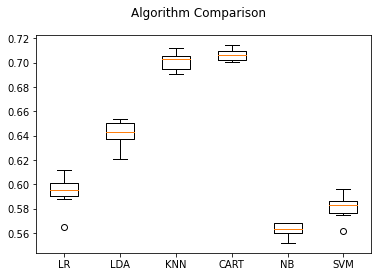

In [ ]:
# Compare Algorithms
fig = pyplot.figure() 
fig.suptitle('Algorithm Comparison') 
ax = fig.add_subplot(111) 
pyplot.boxplot(results) 
ax.set_xticklabels(names) 
pyplot.show()

In [ ]:
# Standardize the dataset
pipelines = []
pipelines.append(('ScaledLR', Pipeline([('Scaler', StandardScaler()),('LR', LogisticRegression())])))
pipelines.append(('ScaledLDA', Pipeline([('Scaler', StandardScaler()),('LDA',LinearDiscriminantAnalysis())])))
pipelines.append(('ScaledKNN', Pipeline([('Scaler', StandardScaler()),('KNN', KNeighborsClassifier())])))
pipelines.append(('ScaledCART', Pipeline([('Scaler', StandardScaler()),('CART', DecisionTreeClassifier())])))
pipelines.append(('ScaledNB', Pipeline([('Scaler', StandardScaler()),('NB', GaussianNB())])))
pipelines.append(('ScaledSVM', Pipeline([('Scaler', StandardScaler()),('SVM', SVC())]))) 
pipelines.append(('ScaledAB', Pipeline([('Scaler', StandardScaler()),('AB', AdaBoostClassifier())]))) 
pipelines.append(('ScaledGBM', Pipeline([('Scaler', StandardScaler()),('GBM', GradientBoostingClassifier())]))) 
pipelines.append(('ScaledRF', Pipeline([('Scaler', StandardScaler()),('RF', RandomForestClassifier())]))) 
pipelines.append(('ScaledET', Pipeline([('Scaler', StandardScaler()),('ET', ExtraTreesClassifier())])))
results = []
names = []
for name, model in pipelines:
  kfold = KFold(n_splits=num_folds, random_state=seed , shuffle= True)
  cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
  results.append(cv_results)
  names.append(name)
  msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
  print(msg)

/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,
/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


ScaledLR: 0.640955 (0.009617)
ScaledLDA: 0.641900 (0.009495)
ScaledKNN: 0.764732 (0.007355)
ScaledCART: 0.709071 (0.007713)
ScaledNB: 0.562791 (0.017301)
ScaledSVM: 0.744674 (0.008823)
ScaledAB: 0.635328 (0.008886)
ScaledGBM: 0.674712 (0.013546)
ScaledRF: 0.786765 (0.010824)
ScaledET: 0.797158 (0.009975)


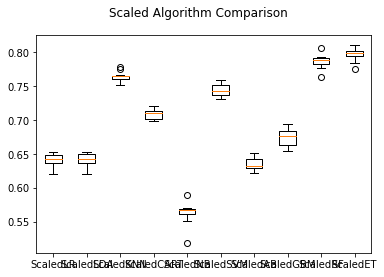

In [ ]:
# Compare Algorithms
fig = pyplot.figure()
fig.suptitle('Scaled Algorithm Comparison') 
ax = fig.add_subplot(111) 
pyplot.boxplot(results) 
ax.set_xticklabels(names)
pyplot.show()

# Tunning

In [ ]:
# Tune scaled SVM
scaler = StandardScaler().fit(X_train)
rescaledX = scaler.transform(X_train)
c_values = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0, 1.3, 1.5, 1.7, 2.0]
kernel_values = ['linear', 'poly', 'rbf', 'sigmoid']
param_grid = dict(C=c_values, kernel=kernel_values)
model = SVC()
kfold = KFold(n_splits=num_folds, random_state=seed, shuffle= True)
grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=kfold) 
grid_result = grid.fit(rescaledX, Y_train)
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

SyntaxError: ignored

# Finalize Model

In [ ]:
"""
# prepare the model
scaler = StandardScaler().fit(X_train)
rescaledX = scaler.transform(X_train)
model = SVC(C=1.5)
model.fit(rescaledX, Y_train)
# estimate accuracy on validation dataset
rescaledValidationX = scaler.transform(X_validation)
predictions = model.predict(rescaledValidationX)
print(accuracy_score(Y_validation, predictions))
print(confusion_matrix(Y_validation, predictions))
print(classification_report(Y_validation, predictions))
"""